In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc #liberacion de memoria ram.
import funciones

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [2]:
#Carga de datos

X_train = np.load('train_data.npy', mmap_mode='r')[:2500000]

print(f"Dimensiones de variables de entrenamiento: {X_train.shape}")

with open('train_data.npy', 'rb') as f:
    _ = np.load(f)          # Saltamos la matriz X
    y_completo = np.load(f)    # Cargamos el vector y en memoria

y_train_muestra = y_completo[:2500000].ravel()

Dimensiones de variables de entrenamiento: (2500000, 190)


In [3]:
#Entrenamiento de modelo LightGBM

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'n_estimators': 150,     
    'max_depth': 7,          
    'random_state': 42,
    'n_jobs': -1             
}

model = lgb.LGBMClassifier(**params)

model.fit(X_train, y_train_muestra)

/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LGBMClassifier(max_depth=7, metric='binary_logloss', n_estimators=150,
               objective='binary', random_state=42)

In [4]:
#GENERACION DE PREDICCIONES POR LOTE

# Volvemos a mapear X completo
X_mmap = np.load('train_data.npy', mmap_mode='r')
total_filas = X_mmap.shape[0]

# Creamos un arreglo vacío para guardar las probabilidades
probabilidades_totales = np.zeros(total_filas, dtype=np.float32)

# Procesamos de 500,000 en 500,000 para cuidar la RAM
tamaño_lote = 500000 

for i in range(0, total_filas, tamaño_lote):
    fin = min(i + tamaño_lote, total_filas)
    
    # Cargamos solo este pedacito a la RAM
    X_chunk = X_mmap[i:fin] 
    
    # Predecimos y guardamos
    probabilidades_totales[i:fin] = model.predict_proba(X_chunk)[:, 1]
    
    print(f"   -> Procesadas filas {i} a {fin}...")

print("Predicciones listas")

/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


   -> Procesadas filas 0 a 500000...


/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


   -> Procesadas filas 500000 a 1000000...


/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

   -> Procesadas filas 4500000 a 5000000...


/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


   -> Procesadas filas 5000000 a 5500000...


/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


   -> Procesadas filas 5500000 a 5850186...
Predicciones listas


In [5]:
len(probabilidades_totales)

5850186

In [6]:
#Seleccion de instancias (estrategia 80/20)
N_TOTAL_OBJETIVO = 750000
PROP_GRIS = 0.8
PROP_SEGURA = 0.2

N_GRIS_REQ = int(N_TOTAL_OBJETIVO * PROP_GRIS)      # 600,000
N_SEGURA_REQ = int(N_TOTAL_OBJETIVO * PROP_SEGURA)  # 150,000

# identificacion de indices
# Zona Gris: Incertidumbre (0.3 a 0.7)
idx_gris_pool = np.where((probabilidades_totales >= 0.3) & (probabilidades_totales <= 0.7))[0]

# Zona Segura: Alta confianza (< 0.1 antimeson o > 0.9 meson)
idx_segura_pool = np.where((probabilidades_totales < 0.2) | (probabilidades_totales > 0.8))[0]

print(f"Eventos - Grises: {len(idx_gris_pool)}, Seguras: {len(idx_segura_pool)}")


Eventos - Grises: 3031656, Seguras: 1702453


In [7]:
# Muestreo aleatorio
# Seleccionamos de la zona gris
n_gris_final = min(N_GRIS_REQ, len(idx_gris_pool))
idx_gris_final = np.random.choice(idx_gris_pool, size=n_gris_final, replace=False)

# Seleccionamos de la zona segura (si faltan grises, podríamos completar con seguras)
n_segura_final = min(N_TOTAL_OBJETIVO - n_gris_final, len(idx_segura_pool))
idx_segura_final = np.random.choice(idx_segura_pool, size=n_segura_final, replace=False)

# combinar ambas listas
idx_finales = np.sort(np.concatenate([idx_gris_final, idx_segura_final]))

print(f"Selección final: {len(idx_finales)} instancias ({len(idx_gris_final)} grises, {len(idx_segura_final)} seguras)")

# Extracción física de los datos
X_train_AG = X_mmap[idx_finales]
y_train_AG = y_completo[idx_finales]

#Guardar archivos para el Algoritmo Genético
np.save('X_train_750k_8020.npy', X_train_AG)
np.save('y_train_750k_8020.npy', y_train_AG)

print(f"Dimensiones: {X_train_AG.shape}")

# Limpieza final de memoria
del X_train_AG, y_train_AG, probabilidades_totales, idx_gris_pool, idx_segura_pool
gc.collect()

Selección final: 750000 instancias (600000 grises, 150000 seguras)
Dimensiones: (750000, 190)


0

In [8]:
X_selecionado = np.load('X_train_750k_8020.npy')
y_seleccionado = np.load('y_train_750k_8020.npy')

# 2. Convertir a DataFrame
# Si tienes la lista de nombres de las 162 variables, cámbiala en 'columns'
df_verificacion = pd.DataFrame(X_selecionado)
df_verificacion['target'] = y_seleccionado

Generando histograma de probabilidades...


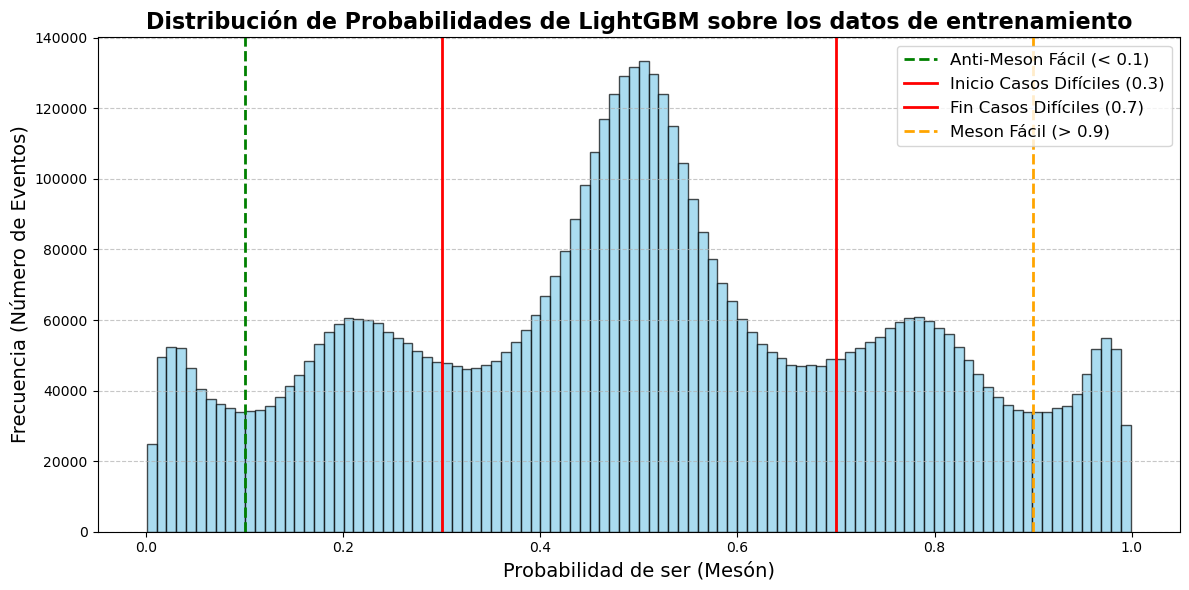

In [5]:
import matplotlib.pyplot as plt
import numpy as np

print("Generando histograma de probabilidades...")

# Crear la figura
plt.figure(figsize=(12, 6))

# Dibujar el histograma
# bins=100 divide el rango de 0 a 1 en 100 barras finas
plt.hist(probabilidades_totales, bins=100, color='skyblue', edgecolor='black', alpha=0.7)

# Agregar líneas para umbrales de probabilidad
plt.axvline(x=0.1, color='green', linestyle='--', linewidth=2, label='Anti-Meson Fácil (< 0.1)')
plt.axvline(x=0.3, color='red', linestyle='-', linewidth=2, label='Inicio Casos Difíciles (0.3)')
plt.axvline(x=0.7, color='red', linestyle='-', linewidth=2, label='Fin Casos Difíciles (0.7)')
plt.axvline(x=0.9, color='orange', linestyle='--', linewidth=2, label='Meson Fácil (> 0.9)')

# Títulos y etiquetas
plt.title('Distribución de Probabilidades de LightGBM sobre los datos de entrenamiento', fontsize=16, fontweight='bold')
plt.xlabel('Probabilidad de ser (Mesón)', fontsize=14)
plt.ylabel('Frecuencia (Número de Eventos)', fontsize=14)


# Mostrar leyenda y cuadrícula
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

In [5]:
#Cargar Test

with open('test_data.npy', 'rb') as file:
    X_test  = np.load(file)
    y_test = np.load(file)

print("X cargado con forma:", X_test.shape)
print("y cargado con forma:", y_test.shape)

X cargado con forma: (731273, 190)
y cargado con forma: (731273, 1)


/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


           train  test
Exactitud   0.73  0.73
F1          0.73  0.73
APS         0.83  0.83
ROC AUC     0.82  0.82


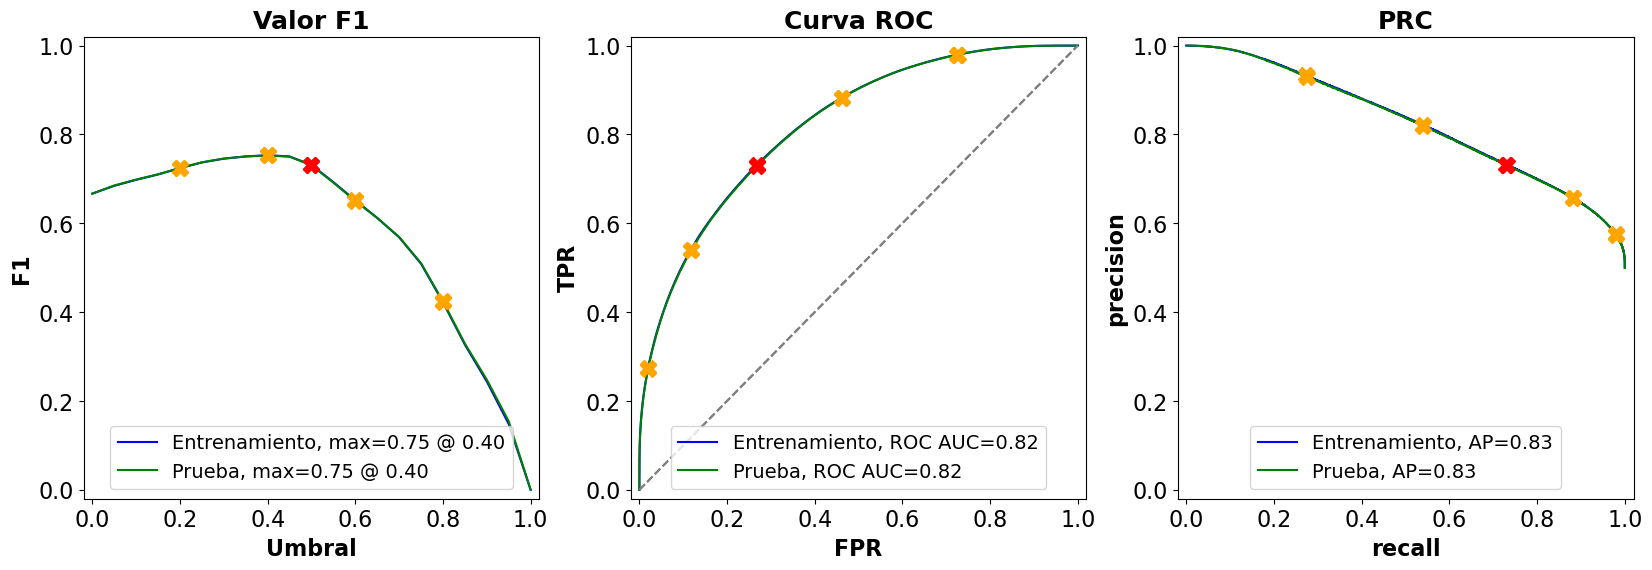

: 

In [ ]:
df_resultados, figura_evaluacion = funciones.evaluate_model(
    model=model, 
    train_features=X_train, 
    train_target=y_train_muestra, 
    test_features=X_test, 
    test_target=y_test
)